In [ ]:
import sqlite3

# Connect and create table
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert some sample data
sample_data = [
    ("Product A", 10, 5.0),
    ("Product B", 20, 7.5),
    ("Product A", 5, 5.0),
    ("Product C", 15, 6.0)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()

Sales Summary:
     product  total_qty  revenue
0  Product A         15     75.0
1  Product B         20    150.0
2  Product C         15     90.0


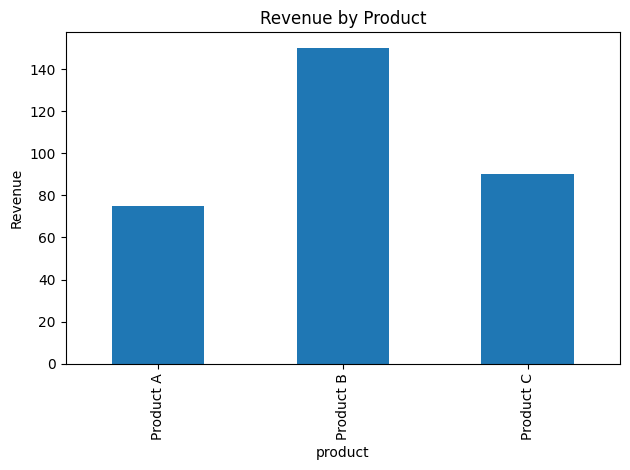

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("sales_data.db")

# SQL Query
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load query result into pandas DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Print the results
print("Sales Summary:")
print(df)

# Plot bar chart of revenue by product
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False)
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig("sales_chart.png")  # Save chart as image
plt.show()
